# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Zahra Sabila Sudrajat
- **Email:** zahra28sabila@gmail.com
- **ID Dicoding:** CDCC002D6X1232

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa total pertumbuhan bulanan (Month-over-Month) untuk nilai transaksi (payment_value) selama satu tahun terakhir, dan kapan puncak penjualannya?
- **Pertanyaan 2:** Kategori produk apa saja yang memiliki rata-rata skor ulasan (review_score) di bawah 4?
- **Pertanyaan 3 :**
Wilayah geografis mana (berdasarkan kota dan state pelanggan) yang memiliki tingkat pembelian tertinggi namun juga menunjukkan tingkat keterlambatan pengiriman paling besar?


## Import Semua Packages/Library yang Digunakan

In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df

In [337]:
df1_customers= pd.read_csv("customers_dataset.csv")
df1_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [338]:
df2_orders_dataset = pd.read_csv("orders_dataset.csv")
df2_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [339]:
df3_products = pd.read_csv("products_dataset.csv")
df3_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [340]:
df4_sellers = pd.read_csv("sellers_dataset.csv")
df4_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [341]:
df5_order_items = pd.read_csv("order_items_dataset.csv")
df5_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [342]:
df6_order_reviews= pd.read_csv("order_reviews_dataset.csv")
df6_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [343]:
df7_product_category= pd.read_csv("product_category_name_translation.csv")
df7_product_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [344]:
df8_geolocation= pd.read_csv("geolocation_dataset.csv")
df8_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [345]:
df9_order_payments = pd.read_csv("order_payments_dataset.csv")
df9_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:** (Opsional)
1. Insight Pelanggan (Customers)
- Konsentrasi Geografis: Identifikasi kota atau negara bagian (customer_state) dengan jumlah pembeli terbanyak untuk target promosi.
- Loyalitas Pelanggan: Menghitung rasio pelanggan yang belanja lebih dari satu kali menggunakan customer_unique_id.

2. Insight Penjualan & Keuangan (Orders & Payments)
- Tren Penjualan: Melihat pola jam, hari, atau bulan tersibuk berdasarkan order_purchase_timestamp.
- Preferensi Pembayaran: Mengetahui metode pembayaran (payment_type) yang paling sering digunakan dan rata-rata jumlah cicilan (payment_installments).
- Revenue vs Ongkir: Membandingkan nilai barang (price) dengan biaya logistik (freight_value) untuk melihat beban ongkir pelanggan.

3. Insight Produk (Products & Categories)
- Kategori top produk: Menentukan kategori produk yang paling laku dan yang menyumbang pendapatan terbesar.
- Logistik Produk: Hubungan berat dan dimensi produk terhadap biaya pengiriman dan kecepatan pengiriman.
- Kualitas Produk: Identifikasi produk yang memiliki performa buruk berdasarkan skor ulasan (review_score).

4. Insight Operasional & Logistik (Delivery & Sellers)
- Kecepatan Pengiriman: Menghitung durasi pengiriman nyata dibandingkan dengan estimasi (order_estimated_delivery_date).
- Performa Seller: Mengukur seberapa cepat penjual menyerahkan barang ke kurir setelah pesanan disetujui.
- Jarak Geospasial: Analisis jarak antara lokasi seller (seller_city) dan pembeli (customer_city) menggunakan data geolocation.

5. Insight Kepuasan (Reviews)
- Analisis Kepuasan: Melihat distribusi rating pelanggan untuk mengevaluasi layanan secara keseluruhan.
- Identifikasi Masalah: Menggali komplain utama melalui review_comment_message (misal: barang rusak, pengiriman lama, atau salah produk).

### Assessing Data

#### Identifying Problem Dataset

In [346]:
df1_customers.info(); print("\n")
print("Jumlah duplikasi data: ", df1_customers.duplicated().sum()) ; print("\n")
print("Jumlah missing value : \n", df1_customers.isna().sum()) ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df1_customers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Jumlah duplikasi data:  0


Jumlah missing value : 
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Check Inaccurate & Inconsistent Value: 



,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [347]:
df2_orders_dataset.info() ; print("\n")
print("Jumlah duplikasi data: ", df2_orders_dataset.duplicated().sum()) ; print("\n")
print("Jumlah missing value : \n", df2_orders_dataset.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Jumlah duplikasi data:  0


Jumlah missing value : 
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_c

In [348]:
df3_products.info() ; print("\n")
print("Jumlah duplikasi data: ", df3_products.duplicated().sum()) ; print("\n")
print("Jumlah missing value : \n ", df3_products.isna().sum()) ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df3_products.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


Jumlah duplikasi data:  0


Jumlah missing value : 
  product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty   

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [349]:
df4_sellers.info(); print("\n")
print("Jumlah duplikasi data: ", df4_sellers.duplicated().sum()) ; print("\n")
print("Jumlah missing value : ") ;df4_sellers.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


Jumlah duplikasi data:  0


Jumlah missing value : 


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [350]:
df5_order_items.info(); print("\n")
print("Jumlah duplikasi data: ", df5_order_items.duplicated().sum()) ; print("\n")
print("Jumlah missing value : ") ;df5_order_items.isna().sum() ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df5_order_items.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Jumlah duplikasi data:  0


Jumlah missing value : 


Check Inaccurate & Inconsistent Value: 



,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [351]:
df6_order_reviews.info(); print("\n")
print("Jumlah duplikasi data: ", df6_order_reviews.duplicated().sum()) ; print("\n")
print("Jumlah missing value : \n", df6_order_reviews.isna().sum())  ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df6_order_reviews.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Jumlah duplikasi data:  0


Jumlah missing value : 
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Check Inaccurate & Inconsistent Value: 



,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [352]:
df7_product_category.info(); print("\n")
print("Jumlah duplikasi data: ", df7_product_category.duplicated().sum()) ; print("\n")
print("Jumlah missing value : ") ; df7_product_category.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


Jumlah duplikasi data:  0


Jumlah missing value : 


,0
product_category_name,0
product_category_name_english,0


In [353]:
df8_geolocation.info() ; print("\n")
print("Jumlah duplikasi data: ", df8_geolocation.duplicated().sum()) ; print("\n")
print("Jumlah missing value : \n", df8_geolocation.isna().sum()) ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df8_geolocation.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Jumlah duplikasi data:  261831


Jumlah missing value : 
 geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Check Inaccurate & Inconsistent Value: 



,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [354]:
df9_order_payments.info() ; print("\n")
print("Jumlah duplikasi data: ", df9_order_payments.duplicated().sum()); print("\n")
print("Jumlah missing value :\n ", df9_order_payments.isna().sum()) ; print("\n")
print("Check Inaccurate & Inconsistent Value: \n");df9_order_payments.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Jumlah duplikasi data:  0


Jumlah missing value :
  order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Check Inaccurate & Inconsistent Value: 



,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Steps to Take:**
1. Check Data Types
- Tujuan: Memastikan kolom tanggal terbaca sebagai datetime, angka sebagai float/int, dan kategori sebagai object.
- Fungsi: df.info()

2. Check Duplicate Data
- Tujuan: Mengidentifikasi adanya baris data yang berulang yang dapat menyebabkan bias pada analisis.
- Fungsi: df.duplicated().sum()
3. Check Missing Values
- Tujuan: Mengetahui kolom mana yang tidak lengkap.
- Fungsi: df.isna().sum()
4. Check Inaccurate & Inconsistent Value
- Tujuan: Mencari nilai yang tidak masuk akal atau penulisan yang berbeda untuk hal yang sama.
- Fungsi: df.describe() (untuk angka) dan df[col].unique() atau df[col].value_counts() (untuk kategori).

**Insight:** (Opsional)
1. Masalah Tipe Data (Inaccurate Data Types)
- Dataset Orders (df2): Kolom yang berhubungan dengan waktu (order_purchase_timestamp, order_approved_at, dll.) masih bertipe Object/String. Ini harus diubah ke Datetime.
- Dataset Order Items (df5): Kolom shipping_limit_date masih bertipe Object dan perlu dikonversi ke format Datetime.

2. Masalah Data Hilang (Missing Values)
- Dataset Orders (df2): Terdapat missing values pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Hal ini kemungkinan terjadi karena pesanan yang dibatalkan atau masih dalam proses pengiriman.
- Dataset Products (df3): Terdapat missing values di hampir seluruh kolom kecuali product_id. Ini menunjukkan adanya data produk yang tidak lengkap spesifikasinya.
- Dataset Reviews (df6): Terdapat missing values pada kolom review_comment_title dan review_comment_message. Hal ini wajar jika pelanggan hanya memberikan skor angka tanpa menulis ulasan teks.

3. Masalah Duplikasi (Duplicate Data)
- Dataset Geolocation (df8): Ditemukan adanya duplikasi data.
- Dataset Lainnya: Untuk df1, df2, df3, df4, df5, df6, df7, dan df9 dikonfirmasi tidak memiliki duplikasi.

4. Status Data Aman (Clean Data)
- Dataset Customers (df1): Tipe data sudah benar, tidak ada duplikasi, dan tidak ada missing value.
- Dataset Sellers (df4): Tipe data sudah benar, tidak ada duplikasi, dan tidak ada missing value.
- Dataset Product Category (df7):  Tipe data sudah benar, tidak ada duplikasi, dan tidak ada missing value.
- Dataset Product (df9): Tipe data aman, tidak ada duplikasi, dan tidak ada missing value.
5. Inaccurate & Inconsistent Value
- Dapat dilihat pada df5 bahwa nilai mean dengan max pada price dan freight_value terbilang cukup jauh, yang menunjukkan kemungkinan adanya outliers pada data tersebut. Untuk order_item_id, perlu diperiksa apakah ada inaccuracy data dari tabel tersebut atau tidak.
- Dapat dilihat pada df9 nilai maksimum pada payment_value, payment sequential, dan payment_installments yang terbilang tinggi dibandingkan dengan nilai mean dan standard deviasinya, mengidentifikasikan bahwa adanya outliers pada data tersebut.

### Cleaning Data

#### Fixing duplicate problem

In [355]:
# Membuat fungsi menghapus duplikat
def drop_duplikat(df):
    # Menghitung duplikat awal
    awal = df.duplicated().sum()
    print(f"Jumlah data duplikat sebelum cleaning: {awal}")

    # Melakukan drop duplicates
    df.drop_duplicates(inplace=True)

    # Menghitung duplikat akhir
    akhir = df.duplicated().sum()
    print(f"Jumlah duplikat setelah cleaning: {akhir}")

In [356]:
drop_duplikat(df8_geolocation)
df8_geolocation.info()

Jumlah data duplikat sebelum cleaning: 261831
Jumlah duplikat setelah cleaning: 0
<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


**Insight:**
Data duplikat berhasil di drop sehingga sekarang data df8 tersebut sudah bersih


#### Fixing Data Type problem


In [357]:
# Mengubah tipe data dari object ke datetime untuk dataset df2
date_time = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for column in date_time:
  df2_orders_dataset[column] = pd.to_datetime(df2_orders_dataset[column])

df2_orders_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [358]:
# Mengubah tipe data dari object ke datetime untuk dataset df5
df5_order_items['shipping_limit_date'] = pd.to_datetime(df5_order_items['shipping_limit_date'])

df5_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### Fixing Inacurracy problem pada tipe data datetime

Urutan: order_purchase_timestamp < order_approved_at < order_delivered_carrier_date < order_delivered_customer_date, dan order_delivered_carrier_date < order_estimated_delivery_date

In [359]:
wrong_order = df2_orders_dataset[
    (df2_orders_dataset['order_purchase_timestamp'] > df2_orders_dataset['order_approved_at']) |
    (df2_orders_dataset['order_approved_at'] > df2_orders_dataset['order_delivered_carrier_date']) |
    (df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_delivered_customer_date'])|
    (df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_estimated_delivery_date'])
]
wrong_order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15
102,a5474c0071dd5d1074e12d417078bbd0,ef15b3240b2083e0487762ee2978d2b8,delivered,2018-07-30 22:41:44,2018-08-01 02:50:15,2018-08-02 10:35:00,2018-08-03 19:28:47,2018-08-02
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,2018-07-31
...,...,...,...,...,...,...,...,...
99091,240ead1a7284667e0ec71d01f80e4d5e,fcdd7556401aaa1c980f8b67a69f95dc,delivered,2018-07-02 16:30:02,2018-07-05 16:17:59,2018-07-05 14:11:00,2018-07-10 23:21:47,2018-07-24
99230,78008d03bd8ef7fcf1568728b316553c,043e3254e68daf7256bda1c9c03c2286,delivered,2018-07-03 13:11:13,2018-07-05 16:32:52,2018-07-03 12:57:00,2018-07-10 17:47:39,2018-07-23
99266,76a948cd55bf22799753720d4545dd2d,3f20a07b28aa252d0502fe7f7eb030a9,delivered,2018-01-30 02:41:30,2018-02-04 23:31:46,2018-01-31 18:11:58,2018-03-18 20:08:50,2018-03-02
99377,a6bd1f93b7ff72cc348ca07f38ec4bee,6d63fa86bd2f62908ad328325799152f,delivered,2018-04-20 17:28:40,2018-04-24 19:26:10,2018-04-23 17:18:40,2018-04-28 17:38:42,2018-05-15


Dapat terlihat banyak data yang salah, sehingga untuk data tersebut perlu diperbaiki valuenya. Misalkan, ada kesalahan pada order_approved_at. Maka datanya aan diubah dengan data order_purchase_timestamp

In [360]:
df2_orders_dataset.loc[df2_orders_dataset['order_purchase_timestamp'] > df2_orders_dataset['order_approved_at'], 'order_approved_at'] = df2_orders_dataset['order_purchase_timestamp']
df2_orders_dataset.loc[df2_orders_dataset['order_approved_at'] > df2_orders_dataset['order_delivered_carrier_date'], 'order_delivered_carrier_date'] = df2_orders_dataset['order_approved_at']
df2_orders_dataset.loc[df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_delivered_customer_date'], 'order_delivered_customer_date'] = df2_orders_dataset['order_delivered_carrier_date']
df2_orders_dataset.loc[df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_estimated_delivery_date'], 'order_estimated_delivery_date'] = df2_orders_dataset['order_delivered_carrier_date']

In [361]:
wrong_order = df2_orders_dataset[
    (df2_orders_dataset['order_purchase_timestamp'] > df2_orders_dataset['order_approved_at']) |
    (df2_orders_dataset['order_approved_at'] > df2_orders_dataset['order_delivered_carrier_date']) |
    (df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_delivered_customer_date'])|
    (df2_orders_dataset['order_delivered_carrier_date'] > df2_orders_dataset['order_estimated_delivery_date'])
]
wrong_order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Data yang sebelumnya salah sudah tidak ada.

#### Fixing Missing Value problem


In [362]:
# Mengecek Missing value pada df2 dataset orders
df2_orders_dataset.isna().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Dapat terlihat banyak missing value

In [363]:
df2_orders_dataset.loc[df2_orders_dataset['order_approved_at'].isna(), 'order_approved_at'] = df2_orders_dataset['order_purchase_timestamp']
df2_orders_dataset.loc[df2_orders_dataset['order_delivered_carrier_date'].isna(), 'order_delivered_carrier_date'] = df2_orders_dataset['order_approved_at']
df2_orders_dataset.loc[df2_orders_dataset['order_delivered_customer_date'].isna(), 'order_delivered_customer_date'] = df2_orders_dataset['order_delivered_carrier_date']

In [364]:
df2_orders_dataset.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


Terlihat sudah tidak ada missing value

In [365]:
# Menghapus kolom yang memiliki missing value pada df3
print("Jumlah missing value sebelum cleaning \n",df3_products.isna().sum())
df3_products = df3_products.dropna()
print("Jumlah missing value setelah cleaning\n",df3_products.isna().sum())

Jumlah missing value sebelum cleaning 
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Jumlah missing value setelah cleaning
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


### Fixing Inaccurate & Inconsistent Value


In [366]:
# Pemeriksaan outliers pada kolom price dan freight_value.
print("Top 5 price termahal: \n",df5_order_items.nlargest(5, 'price'))
print("Top 5 price termurahl: \n",df5_order_items.nsmallest(5, 'price'))

Top 5 price termahal: 
                                 order_id  order_item_id  \
3556    0812eb902a67711a1cb742b3cdaa65ae              1   
112233  fefacc66af859508bf1a7934eab1e97f              1   
107841  f5136e38d1a14a4dbd87dff67da82701              1   
74336   a96610ab360d42a2e5335a3998b4718a              1   
11249   199af31afc78c699f0dbf71fb178d4d4              1   

                              product_id                         seller_id  \
3556    489ae2aa008f021502940f251d4cce7f  e3b4998c7a498169dc7bce44e6bb6277   
112233  69c590f7ffc7bf8db97190b6cb6ed62e  80ceebb4ee9b31afb6c6a916a574a1e2   
107841  1bdf5e6731585cf01aa8169c7028d6ad  ee27a8f15b1dded4d213a468ba4eb391   
74336   a6492cc69376c469ab6f61d8f44de961  59417c56835dd8e2e72f91f809cd4092   
11249   c3ed642d592594bb648ff4a04cee2747  59417c56835dd8e2e72f91f809cd4092   

       shipping_limit_date   price  freight_value  
3556   2017-02-16 20:37:36  6735.0         194.31  
112233 2018-08-02 04:05:13  6729.0         193.2

In [367]:
products_in_english_df = pd.merge(
    left=df3_products,
    right=df7_product_category,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)

In [368]:
order_items_product_df = pd.merge(
    left=df5_order_items,
    right=products_in_english_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
)
descending_order_products = order_items_product_df.sort_values(by='price', ascending=False)
descending_order_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31,utilidades_domesticas,31.0,875.0,2.0,30000.0,60.0,61.0,33.0,housewares
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21,pcs,50.0,1935.0,4.0,5660.0,54.0,18.0,47.0,computers
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66,artes,28.0,3954.0,2.0,7400.0,47.0,25.0,25.0,art
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34,eletroportateis,41.0,1780.0,2.0,22600.0,55.0,40.0,40.0,small_appliances
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34,eletroportateis,59.0,2217.0,2.0,30000.0,50.0,49.0,50.0,small_appliances


In [369]:
ascending_order_products = order_items_product_df.sort_values(by='price', ascending=True)
ascending_order_products.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0,construction_tools_construction
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0,construction_tools_construction
87081,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0,construction_tools_construction
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57305,8272b63d03f5f79c56e9e4120aec44ef,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,232.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57306,8272b63d03f5f79c56e9e4120aec44ef,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty


Dari hasil tersebut dapat telihat bahwa tidak ada outlier pada data order_items baik price maupun freight_value. Freight_value yang tinggi mungkin dapat disebabkan karena jarak pengiriman yang jauh. Untuk kolom order_item_id, karena memang banyak item product, maka memiliki banyak order_item_id.

In [370]:
print("Harga payment tertinggi:\n", df9_order_payments.nlargest(5, 'payment_value'))
print("Harga payment terendah:\n", df9_order_payments.nsmallest(5, 'payment_value'))

Harga payment tertinggi:
                                order_id  payment_sequential payment_type  \
52107  03caa2c082116e1d31e67e9ae3700499                   1  credit_card   
34370  736e1922ae60d0d6a89247b851902527                   1       boleto   
41419  0812eb902a67711a1cb742b3cdaa65ae                   1  credit_card   
49581  fefacc66af859508bf1a7934eab1e97f                   1       boleto   
85539  f5136e38d1a14a4dbd87dff67da82701                   1       boleto   

       payment_installments  payment_value  
52107                     1       13664.08  
34370                     1        7274.88  
41419                     8        6929.31  
49581                     1        6922.21  
85539                     1        6726.66  
Harga payment terendah:
                                order_id  payment_sequential payment_type  \
19922  8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822  fa65dad1b0e818e3ccc5cb0e39231352                  14      vouch

In [371]:
order_payments_items_products_df = pd.merge(
    left=order_items_product_df,
    right=df9_order_payments,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

In [372]:
# Berdasarkan Payment value

descending_order_payments = order_payments_items_products_df.sort_values(by='payment_value', ascending=False)
descending_order_payments.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
1693,03caa2c082116e1d31e67e9ae3700499,4,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1690,03caa2c082116e1d31e67e9ae3700499,1,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1691,03caa2c082116e1d31e67e9ae3700499,2,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1696,03caa2c082116e1d31e67e9ae3700499,7,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1692,03caa2c082116e1d31e67e9ae3700499,3,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1697,03caa2c082116e1d31e67e9ae3700499,8,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1695,03caa2c082116e1d31e67e9ae3700499,6,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
1694,03caa2c082116e1d31e67e9ae3700499,5,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
53154,736e1922ae60d0d6a89247b851902527,3,19936fa4f614ee0590d3b77ac83fd648,b37c4c02bda3161a7546a4e6d222d5b2,2018-07-23 04:31:36,1790.0,28.72,telefonia_fixa,34.0,1016.0,2.0,1100.0,20.0,16.0,20.0,fixed_telephony,1.0,boleto,1.0,7274.88
53152,736e1922ae60d0d6a89247b851902527,1,19936fa4f614ee0590d3b77ac83fd648,b37c4c02bda3161a7546a4e6d222d5b2,2018-07-23 04:31:36,1790.0,28.72,telefonia_fixa,34.0,1016.0,2.0,1100.0,20.0,16.0,20.0,fixed_telephony,1.0,boleto,1.0,7274.88


Dari hasil tersebut dapat terlihat bahwa kemungkinan payment_value tinggi karena konsumen membeli dengan jumlah yang banyak.

In [373]:
order_payments_items_products_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
count,117604,117604.000000,117604,117604,117604,117604.000000,117604.000000,115905,115905.000000,115905.000000,115905.000000,115905.000000,115905.000000,115905.000000,115905.000000,115880,117601.000000,117601,117601.000000,117601.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71,NaN,4,NaN,NaN
top,895ab968e7bb0d5659d16cd74cd1650c,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table,NaN,credit_card,NaN,NaN
freq,63,NaN,536,2133,NaN,NaN,NaN,11823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11823,NaN,86769,NaN,NaN
mean,NaN,1.195920,NaN,NaN,2018-01-06 07:26:40.064649216,120.822849,20.045551,NaN,48.767111,786.956628,2.207843,2117.646529,30.309909,16.658194,23.109995,NaN,1.093528,NaN,2.939482,172.686752
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-18 22:13:59.500000,39.900000,13.080000,NaN,42.000000,347.000000,1.000000,300.000000,18.000000,8.000000,15.000000,NaN,1.000000,NaN,1.000000,60.870000
50%,NaN,1.000000,NaN,NaN,2018-01-25 11:57:47.500000,74.900000,16.290000,NaN,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,NaN,1.000000,NaN,2.000000,108.210000
75%,NaN,1.000000,NaN,NaN,2018-05-10 07:50:37.249999872,134.900000,21.190000,NaN,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,NaN,1.000000,NaN,4.000000,189.260000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000,NaN,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,NaN,29.000000,NaN,24.000000,13664.080000


Terlihat bahwa ada perbedaan antara banyaknya order_id dengan value yang unique pada order_id, sehingga perlu mengganti order_item_id dengan order_item dan mengambil nilai maksimalnya dan menggabungkan order_id yang sama.

In [374]:
result_order_payments_items_products_df = order_payments_items_products_df.loc[order_payments_items_products_df.groupby('order_id')['order_item_id'].idxmax()]
result_order_payments_items_products_df.sort_values(by='payment_value', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
1697,03caa2c082116e1d31e67e9ae3700499,8,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.00,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,fixed_telephony,1.0,credit_card,1.0,13664.08
53155,736e1922ae60d0d6a89247b851902527,4,19936fa4f614ee0590d3b77ac83fd648,b37c4c02bda3161a7546a4e6d222d5b2,2018-07-23 04:31:36,1790.00,28.72,telefonia_fixa,34.0,1016.0,2.0,1100.0,20.0,16.0,20.0,fixed_telephony,1.0,boleto,1.0,7274.88
3669,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31,utilidades_domesticas,31.0,875.0,2.0,30000.0,60.0,61.0,33.0,housewares,1.0,credit_card,8.0,6929.31
117164,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21,pcs,50.0,1935.0,4.0,5660.0,54.0,18.0,47.0,computers,1.0,boleto,1.0,6922.21
112537,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66,artes,28.0,3954.0,2.0,7400.0,47.0,25.0,25.0,art,1.0,boleto,1.0,6726.66
20411,2cc9089445046817a7539d90805e6e5a,6,c183fd5d2abf05873fa6e1014ed9e06c,f08a5b9dd6767129688d001acafc21e5,2017-12-04 12:55:46,989.10,24.49,agro_industria_e_comercio,53.0,1461.0,1.0,1500.0,22.0,16.0,24.0,agro_industry_and_commerce,1.0,boleto,1.0,6081.54
77662,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34,eletroportateis,41.0,1780.0,2.0,22600.0,55.0,40.0,40.0,small_appliances,1.0,credit_card,10.0,4950.34
83002,b4c4b76c642808cbe472a32b86cddc95,2,3db0b74faf0d26a6b252528659d6b849,c4f7fee5b0db50e87766f5a4d1b1b758,2018-07-18 12:25:53,2299.95,104.77,cool_stuff,41.0,851.0,1.0,12667.0,39.0,38.0,35.0,cool_stuff,1.0,credit_card,5.0,4809.44
11716,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34,eletroportateis,59.0,2217.0,2.0,30000.0,50.0,49.0,50.0,small_appliances,1.0,credit_card,8.0,4764.34
64931,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78,pcs,55.0,1710.0,2.0,2900.0,35.0,10.0,40.0,computers,1.0,credit_card,8.0,4681.78


Permasalahan pada data tersebut terselesaikan. Ternyata payment_value yang tinggi disebabkan oleh order_id yang menumpuk. Selanjutnya setelah melakukan merge, perlu dicek kembali apakah ada missing value.

In [375]:
result_order_payments_items_products_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,1419
product_name_lenght,1419
product_description_lenght,1419


In [376]:
result_order_payments_items_products_df.dropna(inplace=True)
result_order_payments_items_products_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0


In [377]:
result_order_payments_items_products_df.sort_values(by='payment_sequential', ascending=False)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
114980,fa65dad1b0e818e3ccc5cb0e39231352,1,1aecdb5fa3add74e385f25c6c527a462,06532f10282704ef4c69168b914b77be,2017-04-27 09:10:13,392.55,65.44,ferramentas_jardim,41.0,3544.0,1.0,16400.0,100.0,30.0,30.0,garden_tools,27.0,voucher,1.0,66.02
94177,ccf804e764ed5650cd8759557269dc13,1,8d37ee446981d3790967d0268d6cfc81,1900267e848ceeba8fa32d80c1a5f5a8,2017-06-15 16:15:08,49.99,12.69,cama_mesa_banho,60.0,640.0,1.0,1100.0,16.0,10.0,16.0,bed_bath_table,19.0,voucher,1.0,1.68
63021,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,3d0cd21d41671c46f82cd11176bf7277,2017-08-14 20:43:31,83.80,5.12,utilidades_domesticas,56.0,548.0,8.0,450.0,30.0,20.0,11.0,housewares,17.0,voucher,1.0,16.70
117085,fedcd9f7ccdc8cba3a18defedd1a5547,2,0554911df28fda9fd668ce5ba5949695,7c67e1448b00f6e969d365cea6b010ab,2017-10-05 17:44:41,79.99,22.88,moveis_escritorio,46.0,1058.0,1.0,5200.0,45.0,54.0,15.0,office_furniture,15.0,voucher,1.0,10.66
18402,285c2e15bebd4ac83635ccc563dc71f4,1,bdc3291ab242ec1effc8eb0987850268,dbd66278cbfe1aa1000f90a217ca4695,2017-12-14 11:55:17,29.00,11.85,eletronicos,53.0,830.0,1.0,541.0,19.0,12.0,16.0,electronics,14.0,voucher,1.0,1.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39797,561f47f3e381d23b5ba7853460adf093,1,da0bb22eb8eb2bce31a3784570528efb,3d871de0142ce09b7081e2b9d1733cb1,2018-02-01 11:10:29,79.00,38.10,papelaria,50.0,354.0,3.0,6350.0,38.0,30.0,28.0,stationery,1.0,credit_card,2.0,117.10
39796,561e6fec91c4b5771dad3f613b72c699,1,5b8a5a9417210b1b84b67b9a7aefb935,f457c46070d02cadd8a68551231220dd,2018-02-12 17:15:29,74.90,16.96,informatica_acessorios,58.0,509.0,1.0,117.0,21.0,12.0,13.0,computers_accessories,1.0,credit_card,1.0,91.86
39795,561e1660c58ab3daf4a9176547f0259a,1,bb50f2e236e5eea0100680137654686c,f7ba60f8c3f99e7ee4042fdef03b70c4,2018-03-20 02:55:35,325.00,14.71,beleza_saude,60.0,2644.0,6.0,400.0,34.0,4.0,22.0,health_beauty,1.0,boleto,1.0,339.71
39794,561dd928c7f7e63277e02e6662bcce48,4,bb90206fa281c20f0b4c42a2393b54dd,e9bc59e7b60fc3063eb2290deda4cced,2017-11-14 03:30:56,199.90,17.16,informatica_acessorios,39.0,72.0,1.0,875.0,35.0,14.0,14.0,computers_accessories,1.0,boleto,1.0,868.24


Payment_sequential yang tinggi kemungkinan karena proses pembayaran  yang terbilang cukup banyak. Dan untuk payment_installment (pembayaran cicilan) tergantung dari kesepakatan awal pembelian.

## Exploratory Data Analysis (EDA)

### Explore semua dataset orders dan product

#### Menyatukan dataset orders

In [378]:
orders_item_df = pd.merge(
    left=df2_orders_dataset,
    right=df5_order_items,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
orders_payment_df = pd.merge(
    left=orders_item_df,
    right=df9_order_payments,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

all_orders_df = pd.merge(
    left=orders_payment_df,
    right=df6_order_reviews,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
# Drop kolom yang tidak dibutuhkan
all_orders_df.drop(columns=["review_comment_title", "review_comment_message","review_answer_timestamp", 'shipping_limit_date'], inplace=True)

In [379]:
all_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              119143 non-null  datetime64[ns]
 5   order_delivered_carrier_date   119143 non-null  datetime64[ns]
 6   order_delivered_customer_date  119143 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   order_item_id                  118310 non-null  float64       
 9   product_id                     118310 non-null  object        
 10  seller_id                      118310 non-null  object        
 11  

In [380]:
all_orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_item_id,833
product_id,833


In [381]:
# Drop baris yang memiliki missing value
all_orders_df.dropna(inplace=True)
all_orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_item_id,0
product_id,0


Ketika data digabung, akan menghasilkan banyak missing value. Oleh karena itu, perlu untuk membersihkan missing value tersebut

In [382]:
all_orders_df = all_orders_df.loc[all_orders_df.groupby('order_id')['order_item_id'].idxmax()]

Karena sudah mengubah order_item_id dengan order_item_id yang paling besar, maka kita namakan order_item_id dengan sum_order

In [383]:
all_orders_df.rename(columns={'order_item_id': 'qty_order'}, inplace=True)
all_orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,qty_order,product_id,seller_id,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date
102015,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,2017-09-21 00:00:00
85965,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,2017-05-13 00:00:00
7455,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,2018-01-23 00:00:00
26952,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,2018-08-15 00:00:00
6200,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,2017-03-02 00:00:00


#### Menyatukan Dataset products

In [384]:
df3_products = pd.merge(
    left=df3_products,
    right=df7_product_category,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)

In [385]:
df3_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32340 entries, 0 to 32339
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32340 non-null  object 
 1   product_category_name          32340 non-null  object 
 2   product_name_lenght            32340 non-null  float64
 3   product_description_lenght     32340 non-null  float64
 4   product_photos_qty             32340 non-null  float64
 5   product_weight_g               32340 non-null  float64
 6   product_length_cm              32340 non-null  float64
 7   product_height_cm              32340 non-null  float64
 8   product_width_cm               32340 non-null  float64
 9   product_category_name_english  32327 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [386]:
# Memilih kolom yang akan digunakan
df3_products= df3_products[['product_id', 'product_category_name','product_category_name_english' ]]

# Mengecek missing value kembali
df3_products.isna().sum()

,0
product_id,0
product_category_name,0
product_category_name_english,13


In [387]:
df3_products.dropna(inplace=True)

#### Menyatukan dataset order dan dataset products

In [388]:
orders_products_df = pd.merge(
    left=all_orders_df,
    right=df3_products,
    how='left',
    left_on='product_id',
    right_on='product_id'
)

In [389]:
orders_products_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
qty_order,0
product_id,0



Terdapat missing value karena penyatuan dataset. Kita akan hapus missing value tersebut

In [390]:
orders_products_df.dropna(inplace=True)
orders_products_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
qty_order,0
product_id,0


Melihat product mana yang mempunyai review score tertinggi dan terendah

In [391]:
orders_products_df.groupby(by='product_category_name_english').agg({
    'product_id':'nunique',
    'qty_order':'sum',
    'review_score':'mean'
}).sort_values(by=['review_score','qty_order'], ascending=False)

,product_id,qty_order,review_score
product_category_name_english,,,
cds_dvds_musicals,1,14.0,4.666667
flowers,14,29.0,4.538462
books_general_interest,210,550.0,4.462451
costruction_tools_tools,39,99.0,4.425532
books_technical,122,262.0,4.421260
...,...,...,...
diapers_and_hygiene,12,39.0,3.740741
fashio_female_clothing,25,47.0,3.736842
fashion_male_clothing,84,130.0,3.727273


Dari hasil tersebut dapat terlihat bahwa review score tertinggi ada pada product cds_dvds_musicals dengan score 4.6 (total order 14) dan terendah ada pada security_and_services dengan score 2.5 (total order 2)

Melihat rentang waktu
- Rentang waktu antara pesanan dibuat dan disetujui,
- Rentang waktu dari persetujuan hingga penyerahan ke jasa pengiriman,
- Rentang waktu pengiriman,
- Rentang waktu antara estingan orderan sampai ke tangan customer,
- Rentang waktu dari tanggal pemesanan hingga orderan sampai ke tangan customer

In [392]:
orders_products_df.order_status.unique()

array(['delivered', 'shipped', 'canceled', 'invoiced', 'processing',
       'approved', 'unavailable'], dtype=object)

In [393]:
# Rentang waktu antara pesanan dibuat dan disetujui
# Daftar status yang ingin kamu ambil
status_target = ['delivered', 'shipped', 'invoiced', 'processing', 'approved']

# Memfilter baris dan menduplikasi hasilnya ke dataframe baru
orders_products_copy = orders_products_df[orders_products_df['order_status'].isin(status_target)].copy()
apply_time = orders_products_copy['order_approved_at'] - orders_products_copy['order_purchase_timestamp']
apply_time = apply_time.apply(lambda x: x.total_seconds())
orders_products_df['apply_time'] = round(apply_time/86400)

In [394]:
# Rentang waktu dari persetujuan hingga penyerahan ke jasa pengiriman
shipped_time = orders_products_copy.loc[orders_products_copy['order_status'] != 'created']
shipped_time = shipped_time['order_delivered_carrier_date'] - shipped_time['order_approved_at']
shipped_time = shipped_time.apply(lambda x: x.total_seconds())
orders_products_df['shipped_time'] = round(shipped_time/86400)

In [395]:
# Rentang waktu pengiriman
customer_gets_order = orders_products_copy.loc[~orders_products_copy['order_status'].isin(['created', 'processing', 'approved', 'invoiced'])]
customer_gets_order = customer_gets_order['order_delivered_customer_date'] - customer_gets_order['order_delivered_carrier_date']
customer_gets_order = customer_gets_order.apply(lambda x: x.total_seconds())
orders_products_df['customer_gets_order'] = round(customer_gets_order/86400)

In [396]:
# Rentang waktu antara estimasi orderan dari pemesanan
estimated_range = orders_products_copy.loc[~orders_products_copy['order_status'].isin(['created', 'processing', 'approved', 'invoiced'])]
estimed_range = estimated_range['order_estimated_delivery_date'] - estimated_range['order_delivered_carrier_date']
estimed_range = estimed_range.apply(lambda x: x.total_seconds())
orders_products_df['estimated_range'] = round(estimed_range/86400)

In [397]:
# Rentang waktu dari tanggal pemesanan hingga orderan sampai ke tangan customer
range_order = orders_products_copy['order_delivered_customer_date'] - orders_products_copy['order_purchase_timestamp']
range_order = range_order.apply(lambda x: x.total_seconds())
orders_products_df['range_order'] = round(range_order/86400)

In [398]:
orders_products_df.agg({
    'apply_time':['mean', 'min', 'max'],
    'shipped_time':['mean', 'min', 'max'],
    'customer_gets_order':['mean', 'min', 'max'],
    'estimated_range':['mean','min','max'],
    'range_order':['mean', 'min', 'max']
})

,apply_time,shipped_time,customer_gets_order,estimated_range,range_order
mean,0.423077,2.789362,9.148973,20.382876,12.309179
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,60.000000,107.000000,205.000000,148.000000,208.000000


Kesimpulan:

- Rentang waktu antara pesanan dibuat dan disetujui adalah 0 sampai 60 hari, dengan rata-rata kurang dari 1 hari (0,42 hari).
- Rentang waktu dari persetujuan hingga penyerahan ke jasa pengiriman adalah 0 sampai 107 hari, dengan rata-rata 2-3 hari.
- Rentang waktu pengiriman adalah 0 hingga 205 hari, dengan rata-rata 9 hari
- Rentang waktu antara estimasi orderan sampai ke tangan customer adalah 0 - 148 hari, dengan rata-rata estimasi pengiriman 20-21 hari.
- Rentang waktu waktu tanggal pemesanan hingga orderan sampai ke tangan customer adalah 0 hingga 208 hari dengan rata-rata 12 hari.

#### Melihat rating penilaian dari jumlah order.

In [399]:
orders_products_df.groupby(by='review_score').agg({
    'qty_order': 'sum',
    'product_category_name_english': 'unique',
    'payment_value': ['min', 'max']
}).sort_values(('qty_order', 'sum'), ascending=False)

qty_order                      product_category_name_english  \
                   sum                                             unique   
review_score                                                                
5.0            62324.0  [cool_stuff, furniture_decor, garden_tools, he...   
4.0            20900.0  [pet_shop, perfumery, housewares, telephony, b...   
1.0            13834.0  [health_beauty, perfumery, bed_bath_table, com...   
3.0             9259.0  [cool_stuff, bed_bath_table, telephony, perfum...   
2.0             3776.0  [furniture_decor, bed_bath_table, office_furni...   

             payment_value            
                       min       max  
review_score                          
5.0                   0.01   6929.31  
4.0                   0.01   4764.34  
1.0                   0.09  13664.08  
3.0                   0.44   3242.84  
2.0                   0.17   3358.24

Dapat dilihat bahwa ada 6929.31 order yang memberikan rating 5, dan 4764.34 order yang memberikan rating 4, dan 13.664.08 order yang memberikan rating 1. Artinya, perlu ada evaluasi dan perbaikan pada product product_category_name_english yang memiliki rating 1 agar kedepannya tidak terdapat banyak orang yang kecewa terhadap produk tersebut dan tidak menurunkan rating dari product tersebut.

#### Menyatukan dataset customer

In [400]:
df8_geolocation.rename(columns={'geolocation_zip_code_prefix': 'zip_code_prefix'}, inplace=True)
df1_customers.rename(columns={'customer_zip_code_prefix': 'zip_code_prefix'}, inplace=True)

In [401]:
df1_customers = pd.merge(
    left=df1_customers,
    right=df8_geolocation,
    how='left',
    left_on='zip_code_prefix',
    right_on='zip_code_prefix'
)

In [402]:
df1_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10328006 entries, 0 to 10328005
Data columns (total 9 columns):
 #   Column              Dtype  
---  ------              -----  
 0   customer_id         object 
 1   customer_unique_id  object 
 2   zip_code_prefix     int64  
 3   customer_city       object 
 4   customer_state      object 
 5   geolocation_lat     float64
 6   geolocation_lng     float64
 7   geolocation_city    object 
 8   geolocation_state   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 709.2+ MB


In [403]:
df1_customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
zip_code_prefix,0
customer_city,0
customer_state,0
geolocation_lat,278
geolocation_lng,278
geolocation_city,278
geolocation_state,278


In [404]:
df1_customers.dropna()

,customer_id,customer_unique_id,zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.509897,-47.397866,franca,SP
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.497396,-47.399241,franca,SP
2,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.510459,-47.399553,franca,SP
3,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.480940,-47.394161,franca,SP
4,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.515413,-47.398194,franca,SP
...,...,...,...,...,...,...,...,...,...
10328001,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.598092,-46.904582,cotia,SP
10328002,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.594171,-46.908091,cotia,SP
10328003,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.599369,-46.905603,cotia,SP
10328004,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.584425,-46.892014,cotia,SP


In [405]:
df1_customers.describe(include='all')

,customer_id,customer_unique_id,zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,10328006,10328006,1.032801e+07,10328006,10328006,1.032773e+07,1.032773e+07,10327728,10327728
unique,99441,96096,NaN,4119,27,NaN,NaN,5812,27
top,c89b7f5621fd31116496f32f0090687e,31d332d20895c5c0baefe55207a0fead,NaN,rio de janeiro,SP,NaN,NaN,rio de janeiro,SP
freq,779,2181,NaN,940474,3878942,NaN,NaN,940421,3878907
mean,NaN,NaN,3.428918e+04,NaN,NaN,-2.181000e+01,-4.612746e+01,NaN,NaN
std,NaN,NaN,2.741553e+04,NaN,NaN,4.464366e+00,3.644221e+00,NaN,NaN
min,NaN,NaN,1.003000e+03,NaN,NaN,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,NaN,NaN,1.329000e+04,NaN,NaN,-2.357275e+01,-4.797750e+01,NaN,NaN
50%,NaN,NaN,2.625500e+04,NaN,NaN,-2.288202e+01,-4.651987e+01,NaN,NaN
75%,NaN,NaN,3.874000e+04,NaN,NaN,-2.026162e+01,-4.346700e+01,NaN,NaN


Dapat dilihat bahwa seharusnya customer_id dan customer_unique_id memiliki value yang sama antara count dan uniquenya. Artinya, terdapat customer_id yang memiliki id duplicate. Kita akan menyisakan 1 customer_id pada semua unique value.

In [406]:
drop_duplicates = df1_customers.drop_duplicates('customer_id', keep='first')
df1_customers = pd.concat([
    drop_duplicates, df1_customers[~df1_customers.duplicated('customer_id', keep=False)]
])
df1_customers= df1_customers.reset_index(drop=True)

In [407]:
df1_customers = df1_customers.drop_duplicates(subset='customer_id', keep='first').reset_index(drop=True)

In [408]:
df1_customers.describe(include='all')

,customer_id,customer_unique_id,zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,99441,99441,99441.000000,99441,99441,99163.000000,99163.000000,99163,99163
unique,99441,96096,NaN,4119,27,NaN,NaN,4200,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP,NaN,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746,NaN,NaN,13207,41731
mean,NaN,NaN,35137.474583,NaN,NaN,-21.192930,-46.176190,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN,5.620584,4.066202,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN,-36.605374,-72.666706,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN,-23.588296,-48.096342,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN,-22.926905,-46.630764,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN,-20.146615,-43.602775,NaN,NaN


#### Menyatukan Dataset Sellers

In [409]:
df4_sellers.rename(columns={'seller_zip_code_prefix': 'zip_code_prefix'}, inplace=True)

In [410]:
df4_sellers = pd.merge(
    left=df4_sellers,
    right=df8_geolocation,
    how='left',
    left_on='zip_code_prefix',
    right_on='zip_code_prefix'
)

In [411]:
df4_sellers.isna().sum()

,0
seller_id,0
zip_code_prefix,0
seller_city,0
seller_state,0
geolocation_lat,7
geolocation_lng,7
geolocation_city,7
geolocation_state,7


In [412]:
df4_sellers.dropna(inplace=True)

In [413]:
df4_sellers.describe(include='all')

,seller_id,zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,311789,311789.000000,311789,311789,311789.000000,311789.000000,311789,311789
unique,3088,NaN,611,23,NaN,NaN,794,22
top,0afccdb8a34ee5c79f7c06faf2b4d56e,NaN,sao paulo,SP,NaN,NaN,sao paulo,SP
freq,779,NaN,29032,171859,NaN,NaN,22372,168099
mean,NaN,33501.248136,NaN,NaN,-22.871844,-47.333297,NaN,NaN
std,NaN,30394.106560,NaN,NaN,2.840552,2.766167,NaN,NaN
min,NaN,1001.000000,NaN,NaN,-36.605374,-67.884719,NaN,NaN
25%,NaN,13160.000000,NaN,NaN,-23.644279,-48.848391,NaN,NaN
50%,NaN,17580.000000,NaN,NaN,-22.946903,-47.152262,NaN,NaN
75%,NaN,38405.000000,NaN,NaN,-21.602020,-46.410711,NaN,NaN


In [414]:
# Menggabungkan seller yang sama
drop_duplicates = df4_sellers.drop_duplicates('seller_id', keep='first')
df4_sellers = pd.concat([
    drop_duplicates, df4_sellers[~df4_sellers.duplicated('seller_id', keep=False)]
])
df4_sellers= df4_sellers.reset_index(drop=True)

In [415]:
df4_sellers = df4_sellers.drop_duplicates(subset='seller_id', keep='first').reset_index(drop=True)

In [416]:
df4_sellers.describe(include='all')

,seller_id,zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,3088,3088.000000,3088,3088,3088.000000,3088.000000,3088,3088
unique,3088,NaN,611,23,NaN,NaN,595,22
top,63704069d9bd3a75c1cf59babe56004a,NaN,sao paulo,SP,NaN,NaN,sao paulo,SP
freq,1,NaN,693,1847,NaN,NaN,566,1814
mean,NaN,32245.904145,NaN,NaN,-23.052636,-47.369528,NaN,NaN
std,NaN,32697.325786,NaN,NaN,3.192324,2.833707,NaN,NaN
min,NaN,1001.000000,NaN,NaN,-36.605374,-67.809656,NaN,NaN
25%,NaN,7092.500000,NaN,NaN,-23.652529,-49.071508,NaN,NaN
50%,NaN,14940.000000,NaN,NaN,-23.488377,-46.796328,NaN,NaN
75%,NaN,63150.000000,NaN,NaN,-22.275718,-46.523298,NaN,NaN


#### Menggabungkan semua dataset

In [417]:
orders_products_customers_df = pd.merge(
    left=orders_products_df,
    right=df1_customers,
    how='left',
    left_on='customer_id',
    right_on='customer_id'
)

all_df = pd.merge(
    left=orders_products_customers_df,
    right=df4_sellers,
    how='left',
    left_on='seller_id',
    right_on='seller_id'
)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96485 entries, 0 to 96484
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96485 non-null  object        
 1   customer_id                    96485 non-null  object        
 2   order_status                   96485 non-null  object        
 3   order_purchase_timestamp       96485 non-null  datetime64[ns]
 4   order_approved_at              96485 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96485 non-null  datetime64[ns]
 6   order_delivered_customer_date  96485 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96485 non-null  datetime64[ns]
 8   qty_order                      96485 non-null  float64       
 9   product_id                     96485 non-null  object        
 10  seller_id                      96485 non-null  object        
 11  price          

In [418]:
all_df.dropna(inplace=True)

#### Melihat Penjualan Bulanan

In [419]:
all_df.loc[:, 'month_year'] = all_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_salaries = all_df.groupby('month_year')['payment_value'].sum().reset_index()

In [420]:
monthly_salaries.sort_values(by='payment_value', ascending=False)

,month_year,payment_value
18,2018-04,1115553.30
13,2017-11,1113134.69
19,2018-05,1106925.21
17,2018-03,1086877.19
15,2018-01,1033831.77
21,2018-07,998786.11
20,2018-06,988655.20
22,2018-08,966948.27
16,2018-02,938625.79
14,2017-12,804758.63


Terluhat bahwa penjualan dengan revenue terbesar berada pada bulan April 2018, yaitu sebesar 1115553.30 Dollar, dan yang memiliki revenue terkecil berada pada bulan Desember 2016, yaitu sebesar 19.62 Dollar.

#### Melihat top 5 category product terlaris dan tidak terlaris

In [421]:
product_category = all_df.groupby(by='product_category_name_english').agg({
    'product_id': 'nunique',
    'qty_order': 'sum',
    'payment_value': ['min', 'max']
})
product_category.reset_index()

product_category_name_english product_id qty_order payment_value         
                                    nunique       sum           min      max
0     agro_industry_and_commerce         74     211.0          9.34  6081.54
1               air_conditioning        121     289.0         26.00  1642.54
2                            art         50     199.0          5.54  6726.66
3          arts_and_craftmanship         17      24.0         23.88   314.32
4                          audio         57     360.0          4.05   636.98
..                           ...        ...       ...           ...      ...
66                    stationery        798    2466.0          2.31  1784.20
67        tablets_printing_image          8      82.0         10.70   408.56
68                     telephony       1090    4443.0          0.01  2457.44
69                          toys       1332    3993.0          0.01  1782.55
70                 watches_gifts       1286    5862.0          0.27  4445.50

[71 rows x 5 columns]

In [422]:
most_purchases = product_category.sort_values(by=('qty_order', 'sum'), ascending=False)
most_purchases.head(5)

product_id qty_order payment_value         
                                 nunique       sum           min      max
product_category_name_english                                            
bed_bath_table                      2799   10935.0          0.01  2225.69
health_beauty                       2347    9476.0          0.03  2938.17
sports_leisure                      2757    8467.0          0.09  4163.51
furniture_decor                     2422    8107.0          0.01  2276.10
computers_accessories               1566    7668.0          1.05  3736.22

Terlihat bahwa produk dengan kategori yang banyak terjual adalah bed_bath_table sebanyak 10935 buah

In [423]:
least_purchases = product_category.sort_values(by=('qty_order', 'sum'), ascending=True)
least_purchases.head(5)

product_id qty_order payment_value        
                                 nunique       sum           min     max
product_category_name_english                                           
security_and_services                  2       2.0        115.45  209.06
fashion_childrens_clothes              4       5.0         54.09  124.52
la_cuisine                            10      14.0         47.15  426.70
cds_dvds_musicals                      1      14.0         54.94  122.22
arts_and_craftmanship                 17      24.0         23.88  314.32

Terlihat bahwa produk dengan kategori yang sedikit terjual adalah arts_and_craftmanship sebanyak 24 buah

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total pertumbuhan bulanan (Month-over-Month) untuk nilai transaksi (payment_value) selama satu tahun terakhir, dan kapan puncak penjualannya?

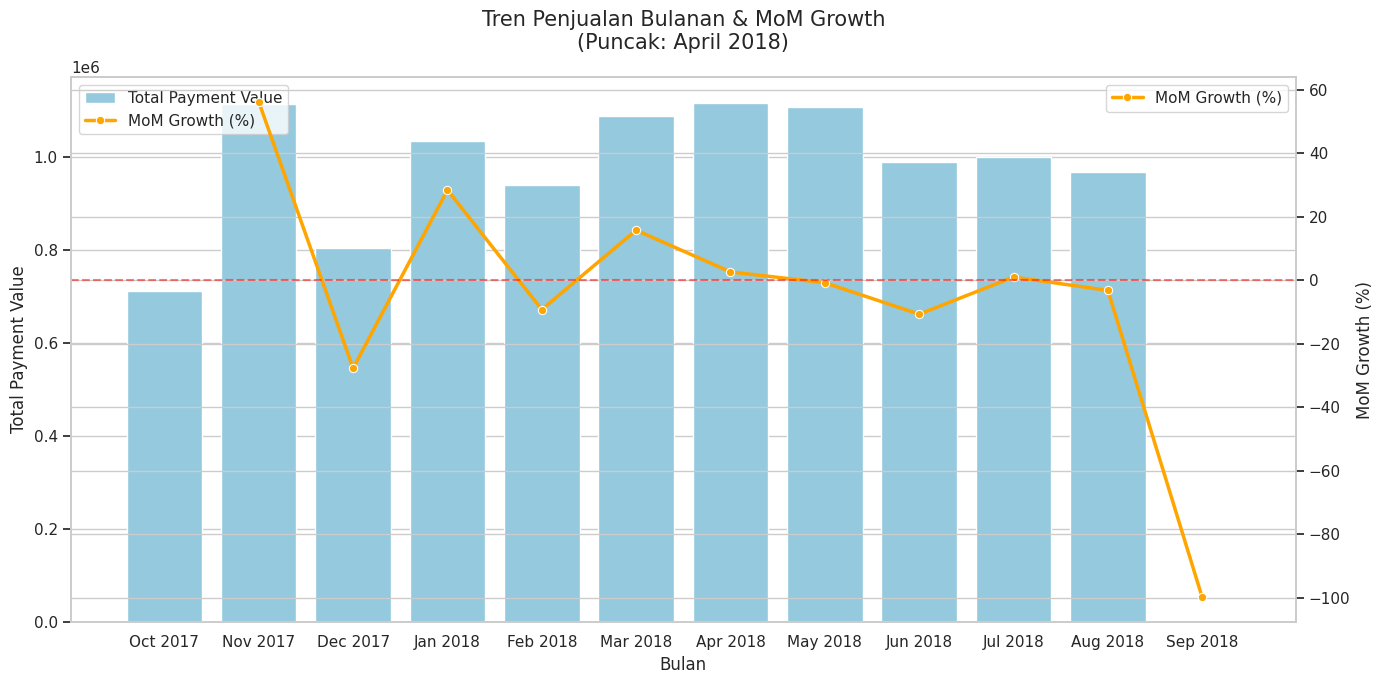

Ringkasan Analisis:
- Puncak Penjualan: April 2018 dengan nilai 1,115,553.30
- Rata-rata Pertumbuhan Bulanan: -4.30%


In [424]:
df = all_df.copy()
# 1. Persiapan Data & Konversi Waktu
# Pastikan 'df' adalah nama dataframe kamu
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Agregasi Penjualan Bulanan
# Kita grouping berdasarkan awal bulan ('MS') untuk memastikan urutan kronologis
monthly_sales = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum().reset_index()
monthly_sales['order_purchase_timestamp'] = monthly_sales['order_purchase_timestamp'].dt.to_timestamp()

# 3. Filter 12 Bulan Terakhir & Hitung MoM
last_year = monthly_sales.sort_values('order_purchase_timestamp').tail(12).copy()
last_year['mom_growth'] = last_year['payment_value'].pct_change() * 100

# 4. Identifikasi Puncak Penjualan
peak_val = last_year['payment_value'].max()
peak_month = last_year.loc[last_year['payment_value'].idxmax(), 'order_purchase_timestamp'].strftime('%B %Y')

# 5. Visualisasi Combo Chart
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar Plot: Nilai Transaksi
sns.barplot(
    x=last_year['order_purchase_timestamp'].dt.strftime('%b %Y'),
    y=last_year['payment_value'],
    ax=ax1,
    color='skyblue',
    label='Total Payment Value'
)

# Line Plot: MoM Growth (%) - Menggunakan Sumbu Y Kedua
ax2 = ax1.twinx()
sns.lineplot(
    x=range(len(last_year)),
    y=last_year['mom_growth'],
    ax=ax2,
    marker='o',
    color='orange',
    linewidth=2.5,
    label='MoM Growth (%)'
)

# Tambahkan Garis Bantu 0% Growth
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

# 6. Styling & Label
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Total Payment Value', fontsize=12)
ax2.set_ylabel('MoM Growth (%)', fontsize=12)
plt.title(f'Tren Penjualan Bulanan & MoM Growth\n(Puncak: {peak_month})', fontsize=15, pad=20)

# Gabungkan Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Print Summary sederhana
print(f"Ringkasan Analisis:")
print(f"- Puncak Penjualan: {peak_month} dengan nilai {peak_val:,.2f}")
print(f"- Rata-rata Pertumbuhan Bulanan: {last_year['mom_growth'].mean():.2f}%")

Analisis Tren Penjualan (Okt 2017 - Sep 2018)
1. Puncak Performa dan Pertumbuhan Tertinggi
- Total Penjualan Tertinggi: Penjualan mencapai titik puncak pada April 2018 dengan nilai pembayaran menembus angka di atas 1,1 juta.
- Lonjakan MoM Terbesar: Pertumbuhan bulanan (MoM Growth) paling drastis terjadi pada November 2017, yang mencapai hampir 60%.

2. Stabilitas dan Fase Pemulihan
- Pemulihan Cepat: Setelah sempat merosot tajam pada Desember 2017, performa langsung bangkit kembali di Januari 2018 dengan kenaikan sekitar 30%.
- Konsistensi Volume: Dari bulan Maret hingga Agustus 2018, bisnis berhasil mempertahankan nilai transaksi yang stabil di atas angka 1 juta per bulan.

3. Anomali Penurunan Akhir Periode
- Penurunan Ekstrem: Terdapat penurunan signifikan pada September 2018


### Pertanyaan 2: Kategori produk apa saja yang memiliki rata-rata skor ulasan (review_score) di bawah 4?

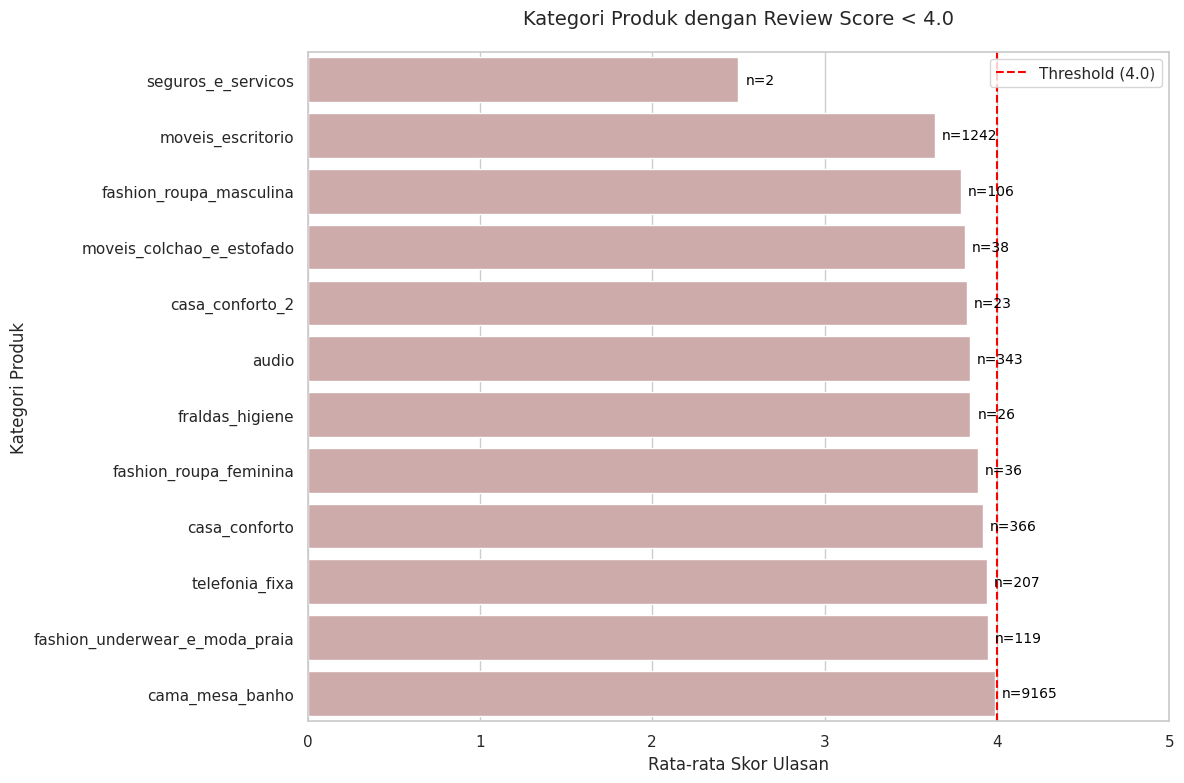

In [425]:
# Lakukan agregasi per kategori produk
product_analysis = all_df.groupby('product_category_name').agg({
    'review_score': 'mean',      # Menghitung rata-rata skor
    'order_id': 'nunique'        # Menghitung jumlah pesanan unik
}).reset_index().copy()

#Rename kolom agar lebih jelas
product_analysis.columns = ['product_category', 'avg_review_score', 'total_orders']

#Filter: Skor < 4.0
bad_performance_categories = product_analysis[
    (product_analysis['avg_review_score'] < 4)
].sort_values(by='avg_review_score')

# Atur  plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Gunakan warna 'Dusty Rose' (#D4A5A5) untuk menunjukkan area peringatan
ax = sns.barplot(
    x='avg_review_score',
    y='product_category',
    data=bad_performance_categories,
    color='#D4A5A5'
)

# Tambahkan garis bantu vertikal di angka 3.0 sebagai batas ambang (threshold)
plt.axvline(x=4.0, color='red', linestyle='--', label='Threshold (4.0)')

# Tambahkan label informasi
plt.title('Kategori Produk dengan Review Score < 4.0', fontsize=14, pad=20)
plt.xlabel('Rata-rata Skor Ulasan', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.xlim(0, 5) # Skala 1-5 sesuai standar rating
plt.legend()

# Tambahkan label jumlah transaksi di setiap bar
for i, p in enumerate(ax.patches):
    total_order = bad_performance_categories.iloc[i]['total_orders']
    ax.annotate(f'n={int(total_order)}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Analisis Kategori Produk dengan Skor Rendah (< 4.0)
1. Prioritas Perbaikan Utama (High Volume, Low Score)
- cama_mesa_banho:  kategori paling kritis karena memiliki jumlah pesanan sangat besar (n=9165) namun rata-rata skornya berada tepat di bawah ambang batas 4.0. Perbaikan kecil pada kategori ini akan berdampak besar pada kepuasan pelanggan secara keseluruhan.
- moveis_escritorio: Memiliki volume transaksi signifikan (n=1242) dengan skor yang jauh lebih rendah dibandingkan rata-rata kategori lainnya. Ini mengindikasikan adanya masalah sistemik pada kualitas produk atau logistik pengiriman furnitur kantor.

2. Kategori dengan Kepuasan Terendah
- seguros_e_servicos: Memiliki rata-rata skor terendah (di bawah 3), namun jumlah transaksinya sangat sedikit (n=2). Skor ini mungkin tidak mewakili performa kategori secara keseluruhan karena ukuran sampel yang sangat kecil.
- fashion_ropa_masculina: Menunjukkan performa yang kurang baik dengan skor di bawah 3.8 dari 106 transaksi. Hal ini perlu diwaspadai karena volume transaksinya sudah cukup untuk dianggap sebagai tren negatif.

### Pertanyaan 3: Wilayah geografis mana (berdasarkan kota dan state pelanggan) yang memiliki tingkat pembelian tertinggi namun juga menunjukkan tingkat keterlambatan pengiriman paling besar?

In [426]:
# 1. Gabungkan data pelanggan dan pesanan
df_geo_delays = all_df.copy()

# 2. Hitung selisih hari keterlambatan (Delay)
# Delay positif berarti terlambat, negatif berarti lebih cepat dari estimasi
df_geo_delays['order_delivered_customer_date'] = pd.to_datetime(df_geo_delays['order_delivered_customer_date'])
df_geo_delays['order_estimated_delivery_date'] = pd.to_datetime(df_geo_delays['order_estimated_delivery_date'])

df_geo_delays['delay_days'] = (df_geo_delays['order_delivered_customer_date'] -
                               df_geo_delays['order_estimated_delivery_date']).dt.days

# 3. Agregasi berdasarkan Kota dan State
geo_analysis = df_geo_delays.groupby(['customer_city', 'customer_state']).agg({
    'order_id': 'count',
    'delay_days': 'mean'
}).reset_index()

# 4. Filter wilayah dengan tingkat pembelian tinggi
top_geo = geo_analysis[geo_analysis['order_id'] > 500].sort_values(by='delay_days', ascending=False)

print(top_geo.head(10))

              customer_city customer_state  order_id  delay_days
3479                 santos             SP       686   -9.556851
726                campinas             SP      1383   -9.755604
3301               salvador             BA      1175  -10.018723
1383          florianopolis             SC       541  -10.070240
1400              fortaleza             CE       627  -10.154705
3494  sao bernardo do campo             SP       891  -10.583614
3628    sao jose dos campos             SP       660  -10.593939
2046                jundiai             SP       539  -10.608534
1560              guarulhos             SP      1128  -10.754433
2499                niteroi             RJ       818  -10.762836


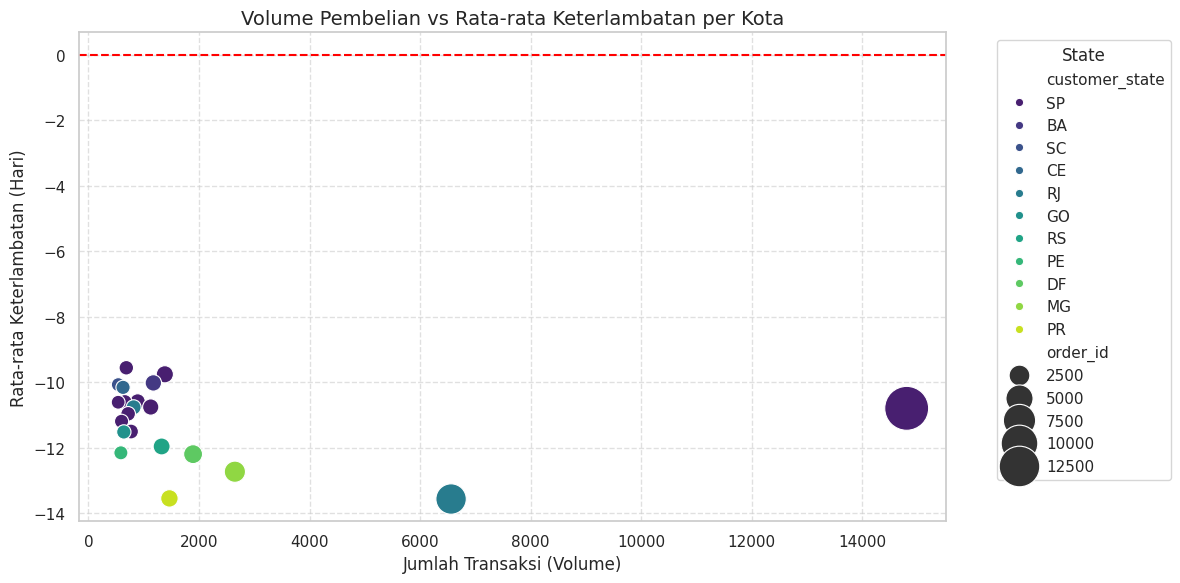

In [427]:
plt.figure(figsize=(12, 6))

# Visualisasi menggunakan Scatter Plot untuk melihat hubungan Volume vs Delay
sns.scatterplot(
    data=top_geo,
    x='order_id',
    y='delay_days',
    hue='customer_state',
    size='order_id',
    sizes=(100, 1000),
    palette='viridis'
)

# Tambahkan garis horizontal di y=0 (estimasi tepat waktu)
plt.axhline(0, color='red', linestyle='--')

plt.title('Volume Pembelian vs Rata-rata Keterlambatan per Kota', fontsize=14)
plt.xlabel('Jumlah Transaksi (Volume)', fontsize=12)
plt.ylabel('Rata-rata Keterlambatan (Hari)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Analisis Efisiensi Logistik Berdasarkan Wilayah
1. Performa Logistik yang Sangat Baik (Over-Delivery)
- Seluruh kota yang ditampilkan berada di bawah garis merah putus-putus (koordinat y negatif).
Hal ini menunjukkan bahwa secara rata-rata, paket sampai ke tangan pelanggan lebih cepat 8 hingga 14 hari dibandingkan estimasi awal yang diberikan sistem.

2. Dominasi Volume di Wilayah SP
-Terdapat satu titik besar di sisi kanan grafik yang mewakili wilayah SP dengan volume transaksi tertinggi, yakni mendekati 15.000 pesanan. Meskipun volumenya sangat besar, wilayah ini tetap menjaga rata-rata pengiriman sekitar 10-11 hari lebih cepat dari estimasi. Hal ini mencerminkan infrastruktur logistik yang sangat matang di pusat ekonomi tersebut.

3. Wilayah dengan Kecepatan Pengiriman Tertinggi
Kota-kota di wilayah RJ (titik teal besar di bagian bawah) dan MG (titik hijau muda) menunjukkan rata-rata pengiriman yang paling efisien, yaitu mencapai 13 hingga 14 hari lebih cepat dari estimasi. Wilayah PR (titik kuning kecil) juga mencatatkan efisiensi waktu yang serupa meskipun dengan volume transaksi yang lebih rendah (di bawah 2.500).

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kinerja penjualan selama Oktober 2017 hingga September 2018 secara umum menunjukkan tren yang positif dengan adanya pertumbuhan signifikan dan periode stabil di level tinggi. Bisnis mampu mencapai puncak performa pada April 2018 serta mempertahankan konsistensi penjualan pada sebagian besar tahun 2018. Meskipun sempat terjadi penurunan di akhir periode, hal tersebut lebih bersifat anomali dibandingkan mencerminkan tren penurunan jangka panjang.
- **Conclusion pertanyaan 2:** Kategori dengan volume tinggi namun skor rendah seperti cama_mesa_banho dan moveis_escritorio menjadi titik kritis karena paling berdampak pada kepuasan pelanggan secara keseluruhan. Sementara itu, kategori dengan skor sangat rendah seperti fashion_ropa_masculina menunjukkan indikasi masalah kualitas yang cukup konsisten, sedangkan seguros_e_servicos belum dapat disimpulkan karena jumlah datanya terlalu kecil.
- **Conclusion pertanyaan 3:** Secara keseluruhan, performa logistik di semua wilayah sangat efisien karena pengiriman konsisten lebih cepat dari estimasi. Wilayah SP menunjukkan kinerja paling stabil dengan volume tinggi dan efisiensi tetap terjaga, sementara RJ dan MG menjadi wilayah dengan kecepatan pengiriman terbaik. Hal ini menandakan sistem logistik sudah berjalan optimal, terutama di pusat dan wilayah dengan infrastruktur kuat.

**Rekomendasi Action Item:**
- Optimalkan strategi yang terbukti meningkatkan penjualan (seperti promosi di periode potensial), jaga konsistensi operasional agar performa tetap stabil, dan evaluasi penyebab penurunan pada September 2018 untuk mencegah kejadian serupa di masa depan.
- Fokuskan perbaikan pada kategori high volume an low score dengan meningkatkan kualitas produk, kontrol vendor, dan proses pengiriman. Lakukan evaluasi khusus pada fashion_ropa_masculina untuk mengatasi penyebab rendahnya kepuasan, serta kumpulkan lebih banyak data pada seguros_e_servicos sebelum mengambil keputusan strategis.
- Pertahankan standar operasional yang sudah efisien, khususnya di wilayah dengan volume tinggi seperti SP. Optimalkan strategi logistik di wilayah dengan performa terbaik (RJ dan MG) sebagai benchmark untuk wilayah lain. Selain itu, evaluasi kembali estimasi waktu pengiriman agar lebih realistis dan tidak terlalu longgar, sehingga meningkatkan kepercayaan dan ekspektasi pelanggan.

In [430]:
# Save data hasil cleaning
all_df.to_csv("all_df.csv")
all_orders_df.to_csv("orders_cleaned.csv")
df3_products.to_csv("products_cleaned.csv")
df1_customers.to_csv("customers_cleaned.csv")
df4_sellers.to_csv("sellers_cleaned.csv")